# Derivation of the Gradient for Mean Squared Error (MSE)

In Linear Regression, we aim to minimize the **Mean Squared Error (MSE)** by adjusting the slope ($m$) and intercept ($c$). This derivation shows how we find the gradient with respect to $m$ to perform **Gradient Descent**.

---

### 1. Define the Cost Function (MSE)
The MSE for $n$ observations is given by:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (mx_i + c - y_i)^2$$

### 2. Apply the Chain Rule
To find the partial derivative with respect to $m$, we apply the **Power Rule** and the **Chain Rule**:
1. **Outer Derivative:** Move the exponent ($2$) to the front.
2. **Inner Derivative:** Take the derivative of the terms inside the parentheses with respect to $m$. Since $\frac{\partial}{\partial m}(mx + c - y) = x$, we multiply the entire expression by $x$.

$$\frac{\partial MSE}{\partial m} = \frac{2}{n} \sum_{i=1}^{n} x_i (mx_i + c - y_i)$$



### 3. Simplified Representation
Substituting the prediction $\hat{y} = mx + c$ back into the equation, we get the final gradient formula used in code:

$$\frac{\partial MSE}{\partial m} = \frac{2}{n} \sum x(\hat{y} - y)$$

---

### Key Takeaway for Implementation
This formula tells us how much to update $m$ in each iteration of Gradient Descent:
**New $m$** = $m - (\text{learning\_rate} \times \text{gradient})$

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
np.random.seed(42)
x = np.linspace(0, 10, 50)
true_m, true_c = 2, 1
y = true_m * x + true_c + np.random.normal(0, 2, size=x.shape)

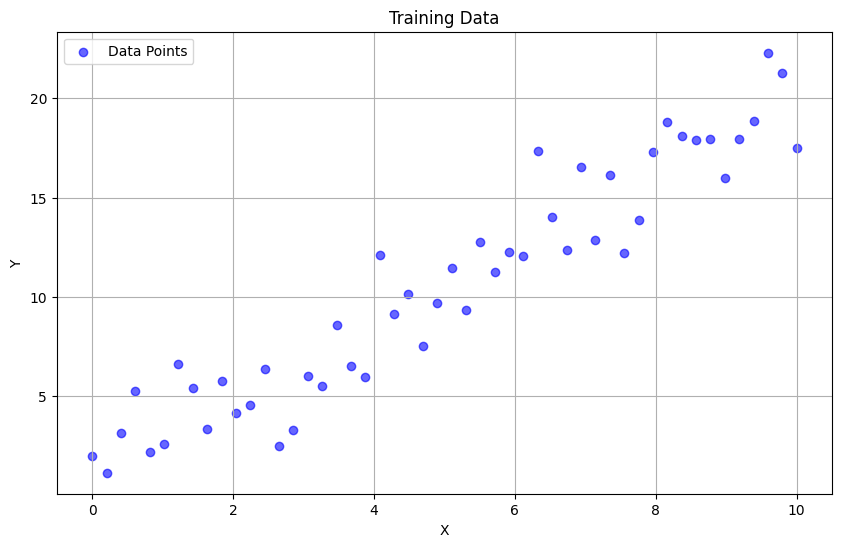

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data Points", color="blue", alpha=0.6)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Training Data")
plt.legend()
plt.grid(True)
plt.savefig("training_data.png")
plt.show()

In [39]:
m, c  = 0.0, 0.0
learning_rate = 0.001
iterations = 10000
loss_history = []

for i in range(iterations):
  y_pred = m * x + c

  ## Compute Gradients
  m_grad = (-2 / len(x)) * np.sum(x * (y - y_pred))
  c_grad = (-2 / len(x)) * np.sum(y - y_pred)

  ## Update Parameters
  m = m - learning_rate * m_grad
  c = c - learning_rate * c_grad

  ## Compute loss (MSE)
  loss = np.mean((y - y_pred) ** 2)
  loss_history.append(loss)

  if i % 100 == 0:
    print(f"Iteration {i:.4f} | Loss = {loss:.4f} | m = {m:.4f} | c = {c:.4f}")

Iteration 0.0000 | Loss = 145.3703 | m = 0.1382 | c = 0.0211
Iteration 100.0000 | Loss = 3.4605 | m = 2.0003 | c = 0.3413
Iteration 200.0000 | Loss = 3.4451 | m = 1.9960 | c = 0.3802
Iteration 300.0000 | Loss = 3.4312 | m = 1.9905 | c = 0.4170
Iteration 400.0000 | Loss = 3.4187 | m = 1.9853 | c = 0.4520
Iteration 500.0000 | Loss = 3.4074 | m = 1.9803 | c = 0.4853
Iteration 600.0000 | Loss = 3.3971 | m = 1.9756 | c = 0.5169
Iteration 700.0000 | Loss = 3.3879 | m = 1.9711 | c = 0.5470
Iteration 800.0000 | Loss = 3.3795 | m = 1.9668 | c = 0.5756
Iteration 900.0000 | Loss = 3.3719 | m = 1.9627 | c = 0.6028
Iteration 1000.0000 | Loss = 3.3651 | m = 1.9589 | c = 0.6287
Iteration 1100.0000 | Loss = 3.3589 | m = 1.9552 | c = 0.6533
Iteration 1200.0000 | Loss = 3.3533 | m = 1.9517 | c = 0.6767
Iteration 1300.0000 | Loss = 3.3482 | m = 1.9484 | c = 0.6989
Iteration 1400.0000 | Loss = 3.3437 | m = 1.9452 | c = 0.7200
Iteration 1500.0000 | Loss = 3.3395 | m = 1.9422 | c = 0.7401
Iteration 1600.000

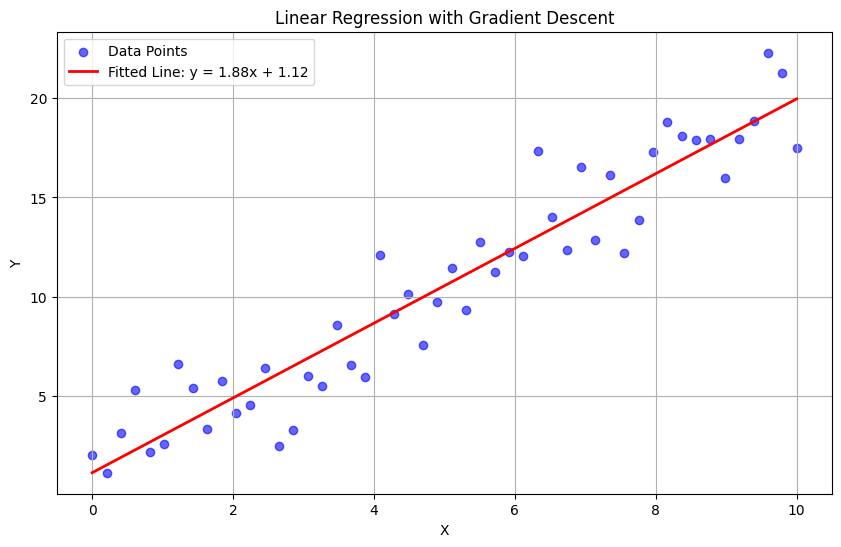

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data Points", color="blue", alpha=0.6)
plt.plot(x, m * x + c, label=f"Fitted Line: y = {m:.2f}x + {c:.2f}", color="red", linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression with Gradient Descent")
plt.legend()
plt.grid(True)
plt.savefig("linear_regression_with_gradient_descent.png")
plt.show()

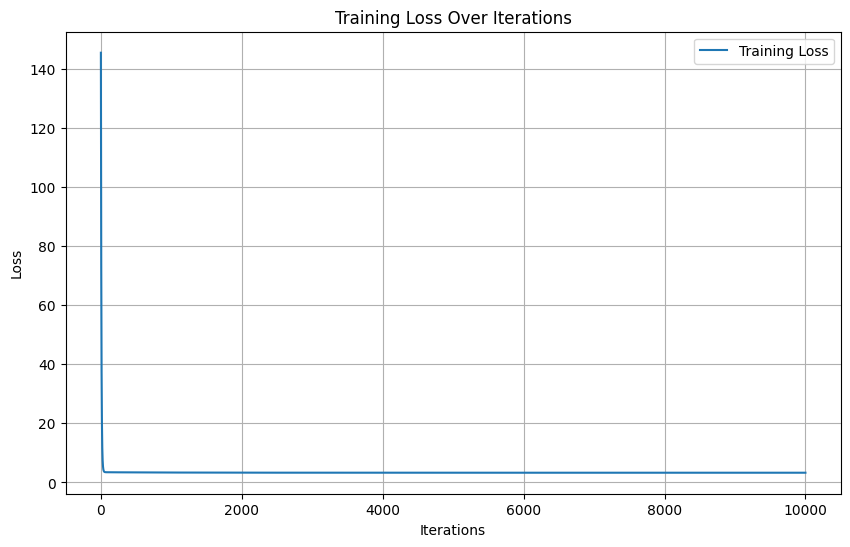

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(range(iterations), loss_history, label='Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Over Iterations')
plt.legend()
plt.grid(True)
plt.savefig("loss_vs_iterations_for_gradient_descent.png")
plt.show()

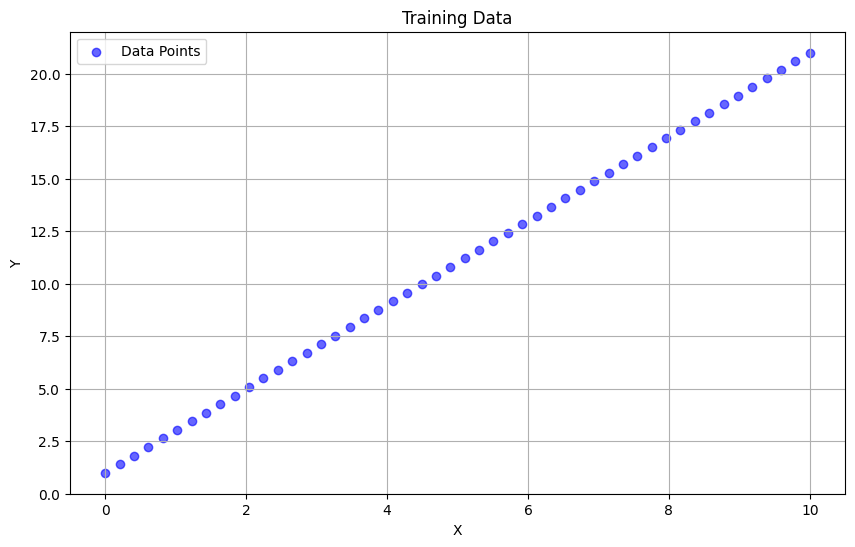

In [42]:
np.random.seed(42)
x = np.linspace(0, 10, 50)
true_m, true_c = 2, 1
y = true_m * x + true_c        ##### Not added Noise

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data Points", color="blue", alpha=0.6)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Training Data")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
m, c  = 0.0, 0.0
learning_rate = 0.001
iterations = 5000
loss_history = []

for i in range(iterations):
  y_pred = m * x + c

  ## Compute Gradients
  m_grad = (-2 / len(x)) * np.sum(x * (y - y_pred))
  c_grad = (-2 / len(x)) * np.sum(y - y_pred)

  ## Update Parameters
  m = m - learning_rate * m_grad
  c = c - learning_rate * c_grad

  ## Compute loss (MSE)
  loss = np.mean((y - y_pred) ** 2)
  loss_history.append(loss)

  if i % 100 == 0:
    print(f"Iteration {i:.4f} | Loss = {loss:.4f} | m = {m:.4f} | c = {c:.4f}")

Iteration 0.0000 | Loss = 155.6939 | m = 0.1447 | c = 0.0220
Iteration 100.0000 | Loss = 0.1095 | m = 2.0959 | c = 0.3483
Iteration 200.0000 | Loss = 0.0989 | m = 2.0927 | c = 0.3806
Iteration 300.0000 | Loss = 0.0894 | m = 2.0881 | c = 0.4110
Iteration 400.0000 | Loss = 0.0809 | m = 2.0838 | c = 0.4400
Iteration 500.0000 | Loss = 0.0731 | m = 2.0797 | c = 0.4675
Iteration 600.0000 | Loss = 0.0661 | m = 2.0757 | c = 0.4937
Iteration 700.0000 | Loss = 0.0598 | m = 2.0720 | c = 0.5186
Iteration 800.0000 | Loss = 0.0540 | m = 2.0685 | c = 0.5423
Iteration 900.0000 | Loss = 0.0489 | m = 2.0651 | c = 0.5648
Iteration 1000.0000 | Loss = 0.0442 | m = 2.0619 | c = 0.5862
Iteration 1100.0000 | Loss = 0.0399 | m = 2.0589 | c = 0.6065
Iteration 1200.0000 | Loss = 0.0361 | m = 2.0560 | c = 0.6258
Iteration 1300.0000 | Loss = 0.0326 | m = 2.0532 | c = 0.6442
Iteration 1400.0000 | Loss = 0.0295 | m = 2.0506 | c = 0.6617
Iteration 1500.0000 | Loss = 0.0267 | m = 2.0481 | c = 0.6784
Iteration 1600.000

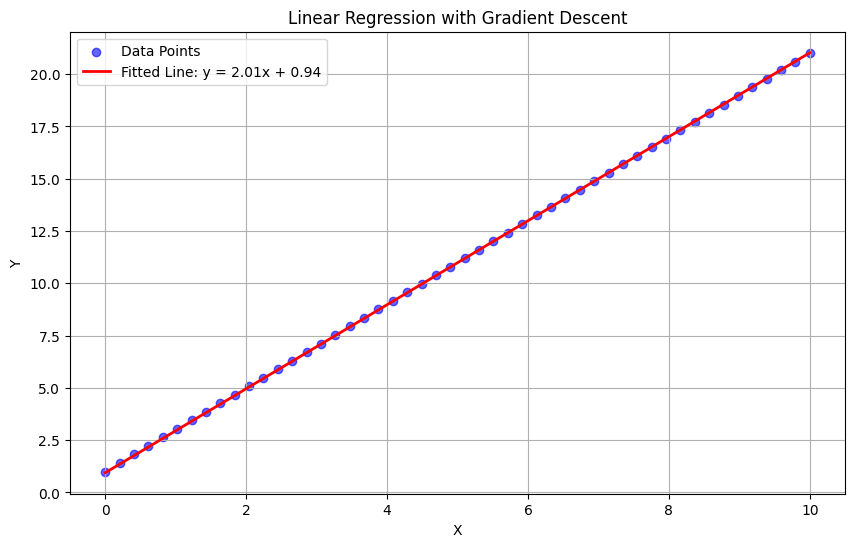

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data Points", color="blue", alpha=0.6)
plt.plot(x, m * x + c, label=f"Fitted Line: y = {m:.2f}x + {c:.2f}", color="red", linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression with Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

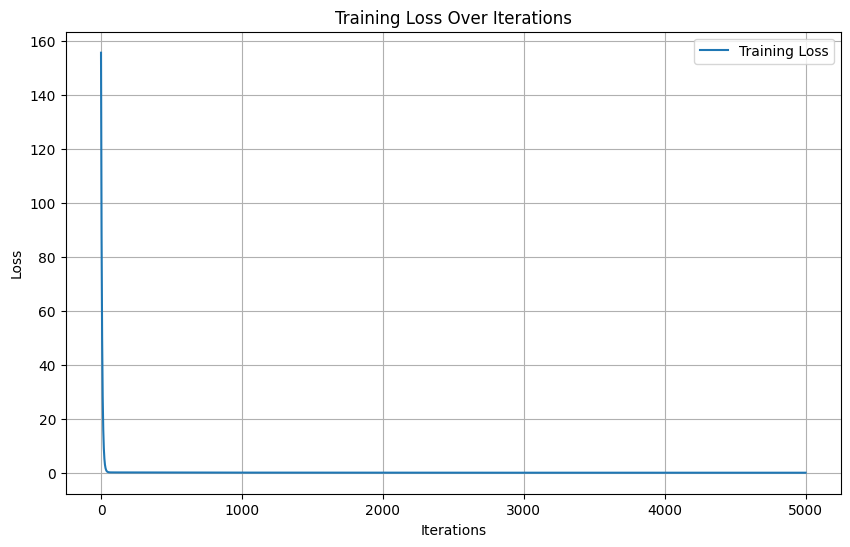

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(range(iterations), loss_history, label='Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Over Iterations')
plt.legend()
plt.grid(True)
plt.show()

# Stochastic Gradient Descent (SGD) and Implementation

In **Stochastic Gradient Descent (SGD)**, we update our model parameters ($\theta$) for every single training example rather than calculating the gradient for the entire dataset at once.

---

### 1. The Update Rule
For every parameter update, you calculate the gradient using **one random data point** $(x^{(i)}, y^{(i)})$:

$$\theta_{new} = \theta_{old} - \eta \cdot \nabla_{\theta} J(\theta; x^{(i)}, y^{(i)})$$

Where:
* **$\theta$**: The parameters (weights) being optimized.
* **$\eta$**: The learning rate.
* **$\nabla_{\theta}(y_i - \hat{y}_i)^2$**: The gradient of the squared error for a single observation.

---

### 2. Mathematical Derivation for a Single Point
To update the slope ($m$), we find the partial derivative of the error for one point $(y_i - mx_i - c)^2$:

$$\frac{\partial}{\partial m} (y_i - mx_i - c)^2 = 2(y_i - mx_i - c) \cdot (-x_i)$$

* **Outer Derivative:** The power of 2 is moved to the front.
* **Inner Derivative:** The derivative of the inside with respect to $m$ is $-x_i$.

---

### 3. Comparison of Cost Functions
The behavior of the cost function over iterations varies significantly between descent methods:

| Method | Cost Function Behavior | Description |
| :--- | :--- | :--- |
| **Batch GD** |  | Reduces smoothly as it uses the entire dataset per step. |
| **SGD** |  | Shows a lot of variations/noise because it updates based on single random points. |
| **Mini-Batch** |  | Smoother than SGD but still has some variation; uses a small group of points. |

---

### 4. Implementation Logic (NumPy)
When implementing gradient descent in code, we often use matrix operations for efficiency.

```python
# Standard Batch Gradient Descent Logic
for epoch in range(epochs):
    predictions = X.dot(theta)          # Calculate y_hat
    errors = predictions - y            # Calculate (y_hat - y)
    gradients = 2 / m * X.T.dot(errors) # Calculate the average gradient
    theta -= lr * gradients             # Update parameters

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [47]:
def generate_data(num_samples):
  np.random.seed(42)
  x = np.random.rand(num_samples, 1) * 10
  y = 2 * x + 4 + np.random.randn(num_samples, 1)
  return x, y

In [48]:
def compute_loss(y_true, y_pred):
  return np.mean((y_true - y_pred) ** 2)

In [49]:
def batch_gradient_descent(x, y, epochs, lr):     ## Vanilla Gradient Descent
  m, n = x.shape
  x = np.c_[np.ones((m, 1)), x]
  theta = np.random.randn(n+1, 1)
  losses = []

  for epoch in range(epochs):
    predictions = x.dot(theta)
    errors = predictions - y
    gradients = 2 / m * x.T.dot(errors)
    theta -= lr * gradients
    loss = compute_loss(y, predictions)
    losses.append(loss)

  return theta, losses

In [50]:
def stochastic_gradient_descent(x, y, epochs, lr):
  m, n = x.shape
  x = np.c_[np.ones((m, 1)), x]
  theta = np.random.randn(n+1, 1)
  losses = []

  for epoch in range(epochs):
    random_index = np.random.randint(m)
    x1 = x[random_index:random_index+1]
    y1 = y[random_index:random_index+1]
    predictions = x1.dot(theta)
    errors = predictions - y1
    gradients = 2 * x1.T.dot(errors)
    theta -= lr * gradients
    loss = compute_loss(y1, predictions)
    losses.append(loss)

  return theta, losses

In [51]:
small_dataset_size = 1000
hugee_dataset_size = 10000000

x_small, y_small = generate_data(small_dataset_size)
x_large, y_large = generate_data(hugee_dataset_size)

In [52]:
start_time = time.time()
small_theta_bgd, small_losses_bgd = batch_gradient_descent(x_small, y_small, epochs=500, lr=0.01)
end_time = time.time()
total_time = end_time - start_time
print(f"Batch Gradient Descent took {total_time:.3f} for small dataset")

start_time = time.time()
larget_theta_bgd, large_losses_bgd = batch_gradient_descent(x_large, y_large, epochs=500, lr=0.01)
end_time = time.time()
total_time = end_time - start_time
print(f"Batch Gradient Descent took {total_time:.3f} for large dataset")

Batch Gradient Descent took 0.015 for small dataset
Batch Gradient Descent took 89.677 for large dataset


In [53]:
start_time = time.time()
small_theta_sgd, small_losses_sgd = stochastic_gradient_descent(x_small, y_small, epochs=500, lr=0.01)
end_time = time.time()
total_time = end_time - start_time
print(f"Stochastic Gradient Descent took {total_time:.3f} for small dataset")

start_time = time.time()
larget_theta_sgd, large_losses_sgd = stochastic_gradient_descent(x_large, y_large, epochs=500, lr=0.01)
end_time = time.time()
total_time = end_time - start_time
print(f"Stochastic Gradient Descent took {total_time:.3f} for large dataset")

Stochastic Gradient Descent took 0.017 for small dataset
Stochastic Gradient Descent took 0.105 for large dataset


In [54]:
print(f"Loss for Small Batch Gradient Descent: {small_losses_bgd[-1]:.4f}")
print(f"Loss for Large Batch Gradient Descent: {large_losses_bgd[-1]:.4f}")
print(f"Loss for Small Stochastic Gradient Descent: {small_losses_sgd[-1]:.4f}")
print(f"Loss for Large Stochastic Gradient Descent: {large_losses_sgd[-1]:.4f}")

Loss for Small Batch Gradient Descent: 1.0070
Loss for Large Batch Gradient Descent: 1.0266
Loss for Small Stochastic Gradient Descent: 2.5827
Loss for Large Stochastic Gradient Descent: 4.8344


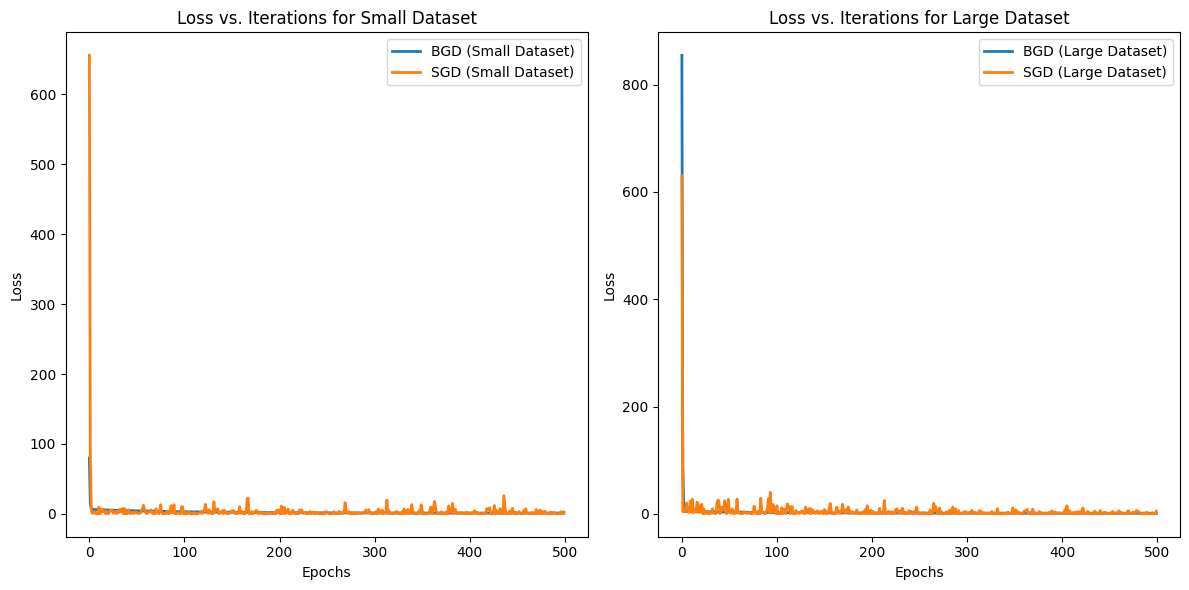

In [56]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(small_losses_bgd, label="BGD (Small Dataset)", linewidth=2.0)
plt.plot(small_losses_sgd, label="SGD (Small Dataset)", linewidth=2.0)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs. Iterations for Small Dataset")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(large_losses_bgd, label="BGD (Large Dataset)", linewidth=2.0)
plt.plot(large_losses_sgd, label="SGD (Large Dataset)", linewidth=2.0)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs. Iterations for Large Dataset")
plt.legend()

plt.tight_layout()
plt.savefig("Loss vs Iterations for Small and Large Datasets.png")
plt.show()

# Gradient Descent with Momentum

**Momentum** is an optimization algorithm that helps accelerate Gradient Descent by dampening oscillations and speeding up convergence. It acts like a ball rolling down a hill, gaining speed in the direction of the steepest descent.

---

### 1. The Core Concept: Velocity
In standard Gradient Descent, we update parameters based only on the current gradient. In Momentum, we introduce a **velocity** term ($V_t$) that remembers previous gradients.

**The Update Rules:**
1.  **Calculate Velocity:** $$V_t = \beta V_{t-1} + (1 - \beta) \nabla J(\theta_t)$$
2.  **Update Parameters:** $$\theta \leftarrow \theta - \eta V_t$$

**Key Variables:**
* **$V_t$**: Current velocity.
* **$V_{t-1}$**: Previous velocity.
* **$\beta$**: Momentum coefficient (typically **0.9** or **0.99**), which controls how much "friction" exists.
* **$\eta$**: Learning rate.
* **$\nabla J(\theta_t)$**: The current gradient.

---

### 2. Physical Intuition: Inertia and Steepness
* **Accelerating on steep slopes:** If the slope remains steep in the same direction, the momentum (velocity) keeps increasing, allowing for faster steps.
* **Handling Flat Terrain:** If the gradient becomes zero (flat terrain), the update does not stop instantly. Instead, the momentum "dies down" slowly, helping the algorithm coast through plateaus.
* **Reducing Oscillations:** Due to **inertia**, it is very difficult to instantly flip the direction of the gradient. This prevents the "zig-zagging" common in standard SGD.


---

### 3. Implementation Logic
When implementing this in Python, we initialize the velocity as an array of zeros and update it at every iteration.

```python
def gradient_descent_momentum(grad_func, eta, beta, epochs, start_point):
    x, y = start_point
    v = np.array([0, 0]) # Initialize velocity
    
    for _ in range(epochs):
        grad = grad_func(x, y) # Get current gradient
        
        # 1. Update velocity (The momentum part)
        v = beta * v + (1 - beta) * grad
        
        # 2. Update parameters using velocity instead of just gradient
        x -= eta * v[0]
        y -= eta * v[1]

In [57]:
import numpy as np
import matplotlib.pyplot as plt

In [58]:
def quadratic_loss_function(x, y):
  return x**2 + 10*y**2

In [59]:
def quadratic_grad(x, y):
  dx = 2 * x
  dy = 20 * y
  return np.array([dx, dy])

In [60]:
def batch_gradient_descent(grad_func, eta, epochs, start_point):
  x, y = start_point
  path = [(x, y)]
  losses = [quadratic_loss_function(x, y)]

  for _ in range(epochs):
    grad = grad_func(x, y)
    x -= eta * grad[0]
    y -= eta * grad[1]
    path.append((x, y))
    losses.append(quadratic_loss_function(x, y))

  return np.array(path), losses

In [61]:
def gradient_descent_momentum(grad_func, eta, beta, epochs, start_point):
  x, y = start_point
  v = np.array([0, 0])
  path = [(x, y)]
  losses = [quadratic_loss_function(x, y)]

  for _ in range(epochs):
    grad = grad_func(x, y)
    v = beta * v + (1 - beta) * grad
    x -= eta * v[0]
    y -= eta * v[1]
    path.append((x, y))
    losses.append(quadratic_loss_function(x, y))

  return np.array(path), losses

In [62]:
def plot_path(function, paths, labels, title):
  x, y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
  z = function(x, y)

  plt.figure(figsize=(14, 8))
  plt.contour(x, y, z, levels=50, cmap='viridis')

  for path, label in zip(paths, labels):
    plt.plot(path[:, 0], path[:, 1], label=label)
    plt.scatter(path[0, 0], path[0, 1], color='red', marker='o', label='Start')
    plt.scatter(path[-1, 0], path[-1, 1], color='green', marker='x', label='End')

  plt.title(title)
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.legend()
  plt.grid(True)
  plt.savefig("Oscillation in BGD vs Momentum.png")
  plt.show()

In [63]:
def plot_loss(losses, labels, title):
  plt.figure(figsize=(10, 6))

  for loss, label in zip(losses, labels):
    plt.plot(loss, label=label)

  plt.title(title)
  plt.xlabel('Iterations')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.savefig("Loss vs Iterations in BGD vs Momentum.png")
  plt.show()

In [64]:
path_bgd, losses_bgd = batch_gradient_descent(quadratic_grad,
                                              eta=0.1,
                                              epochs=100,
                                              start_point=(1.0, 1.0)
                                            )

In [65]:
path_momentum, losses_momentum = gradient_descent_momentum(
                                  quadratic_grad,
                                  eta=0.1,
                                  beta=0.9,
                                  epochs=100,
                                  start_point=(1.0, 1.0)
                                )

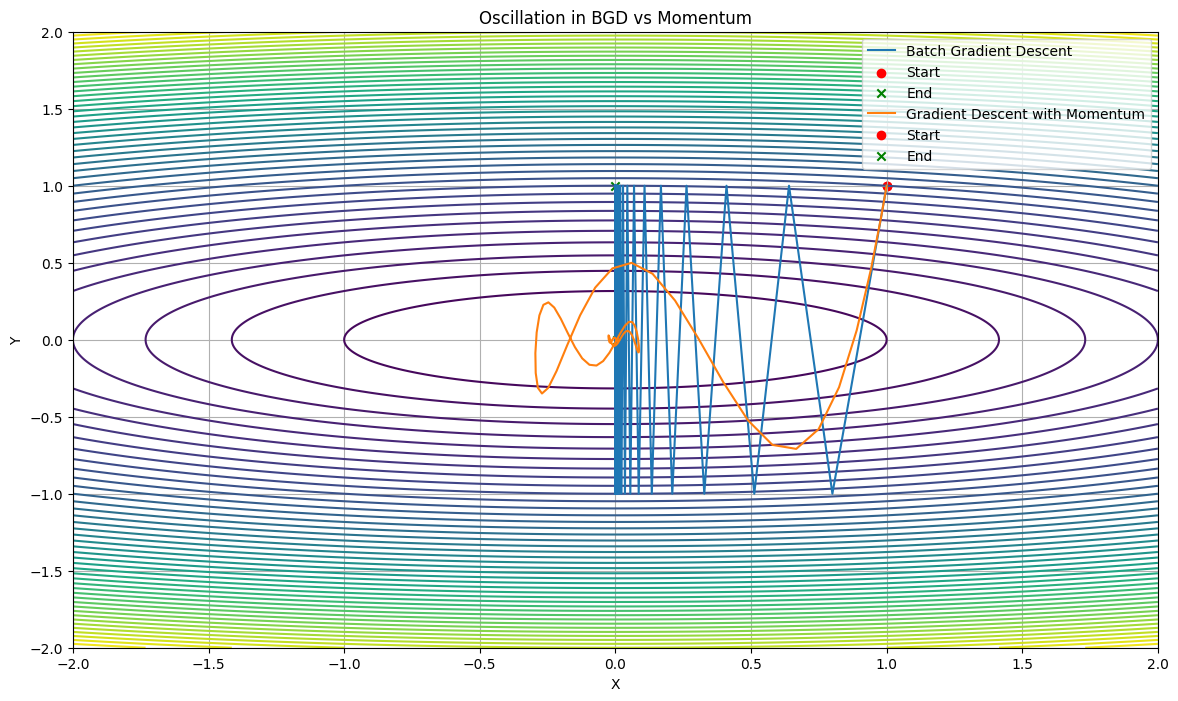

In [66]:
plot_path(quadratic_loss_function, [path_bgd, path_momentum],
          ["Batch Gradient Descent", "Gradient Descent with Momentum"],
          "Oscillation in BGD vs Momentum")

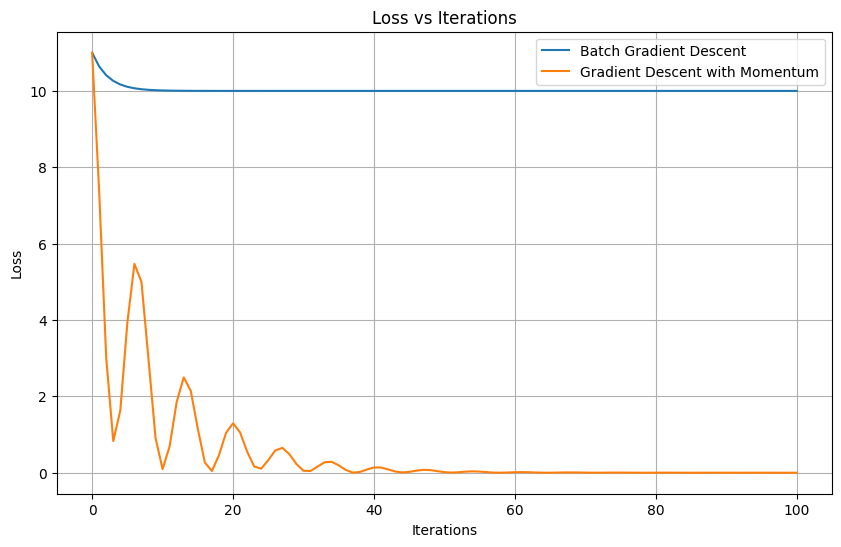

In [67]:
plot_loss([losses_bgd, losses_momentum],
          ["Batch Gradient Descent", "Gradient Descent with Momentum"],
          "Loss vs Iterations")

# RMSprop Optimization Algorithm

**RMSprop** is an adaptive learning rate method designed to resolve the radically different magnitudes of gradients for different parameters. It is particularly effective at dampening oscillations in steep directions while accelerating progress in flatter regions.

---

### 1. The Core Benefits
RMSprop improves upon standard Gradient Descent in two primary ways:
1.  **Dampens Oscillations:** It normalizes large gradients (often found in steep valleys), leading to smaller, more stable steps in those directions.
2.  **Speeds Up Convergence:** It scales the learning rate based on the magnitude of recent gradients, allowing for faster movement in flatter regions of the cost function.

> **Note:** Unlike Momentum, RMSprop does **not** incorporate a velocity term; it focuses solely on scaling the gradient magnitude.

---

### 2. Mathematical Steps

#### Step 1: Compute Gradients
For each parameter $\theta_t$, calculate the gradient of the loss function:
$$g_t = \nabla_{\theta} J(\theta_t)$$

#### Step 2: Maintain a Moving Average of Squared Gradients
Instead of using the raw gradient, RMSprop keeps track of an **exponentially weighted moving average** of the squares of the gradients:
$$E[g^2]_t = \beta E[g^2]_{t-1} + (1 - \beta) g^2_t$$
* **$\beta$ (Decay Rate):** Typically set to **0.9**.
* **$g^2_t$:** The squared gradient at the current step.


#### Step 3: Scale the Gradient and Update
The parameters are updated by scaling the learning rate ($\eta$) by the square root of the moving average:
$$\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{E[g^2]_t} + \epsilon} g_t$$
* **$\epsilon$ (Epsilon):** A very small constant (e.g., $10^{-8}$) added to the denominator to **avoid division by zero**.

---

### 3. Implementation Logic (Python)
The following logic demonstrates how the moving average (`Eg2`) is used to adaptively scale the updates for each coordinate independently.

```python
def rmsprop_optimizer(grad_func, lr, beta, epsilon, epochs, start_point):
    x, y = start_point
    Eg2 = np.array([0.0, 0.0]) # Initialize moving average of squared gradients
    
    for _ in range(epochs):
        grad = grad_func(x, y)
        
        # 1. Update moving average of squared gradients
        Eg2 = beta * Eg2 + (1 - beta) * (grad ** 2)
        
        # 2. Update parameters with adaptive scaling
        x -= lr * grad[0] / (np.sqrt(Eg2[0]) + epsilon)
        y -= lr * grad[1] / (np.sqrt(Eg2[1]) + epsilon)

In [68]:
import numpy as np
import matplotlib.pyplot as plt

In [69]:
def quadratic_loss_function(x, y):
  return x**2 + 10*y**2

In [70]:
def quadratic_grad(x, y):
  dx = 2 * x
  dy = 20 * y
  return np.array([dx, dy])

In [71]:
def batch_gradient_descent(grad_func, eta, epochs, start_point):
  x, y = start_point
  path = [(x, y)]
  losses = [quadratic_loss_function(x, y)]

  for _ in range(epochs):
    grad = grad_func(x, y)
    x -= eta * grad[0]
    y -= eta * grad[1]
    path.append((x, y))
    losses.append(quadratic_loss_function(x, y))

  return np.array(path), losses

In [72]:
def rmsprop_optimizer(grad_func, lr, beta, epsilon, epochs, start_point):
  x, y = start_point
  eg2 = np.array([0.0, 0.0])
  path = [(x, y)]
  losses = [quadratic_loss_function(x, y)]

  for _ in range(epochs):
    grad = grad_func(x, y)
    eg2 = beta * eg2 + (1 - beta) * (grad ** 2)   ## Update moving average

    x -= lr * grad[0] / (np.sqrt(eg2[0]) + epsilon)
    y -= lr * grad[1] / (np.sqrt(eg2[1]) + epsilon)

    path.append((x, y))
    losses.append(quadratic_loss_function(x, y))

  return np.array(path), losses

In [73]:
def plot_paths(grad_function, paths, labels, title):
  x, y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
  z = grad_function(x, y)

  plt.figure(figsize=(14, 8))
  plt.contour(x, y, z, levels=50, cmap='viridis')

  for path, label in zip(paths, labels):
    plt.plot(path[:, 0], path[:, 1], label=label)
    plt.scatter(path[0, 0], path[0, 1], color='red', marker='o', label='Start')
    plt.scatter(path[-1, 0], path[-1, 1], color='green', marker='x', label='End')

  plt.title(title)
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.legend()
  plt.grid(True)
  plt.savefig("Optimization Path: RMSProp vs BGD.png")
  plt.show()

In [74]:
def plot_loss(losses, labels, title):
  plt.figure(figsize=(10, 6))

  for loss, label in zip(losses, labels):
    plt.plot(loss, label=label)

  plt.title(title)
  plt.xlabel('Iterations')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.savefig("Loss vs Iterations: RMSProp vs BGD.png")
  plt.show()

In [75]:
path_rms, losses_rms = rmsprop_optimizer(
                grad_func=quadratic_grad,
                lr=0.1,
                beta=0.9,
                epsilon=1e-8,
                epochs=100,
                start_point=(1.0,1.0)
              )

In [76]:
path_bgd, losses_bgd = batch_gradient_descent(
                        grad_func=quadratic_grad,
                        eta=0.1,
                        epochs=100,
                        start_point=(1.0,1.0)
                      )

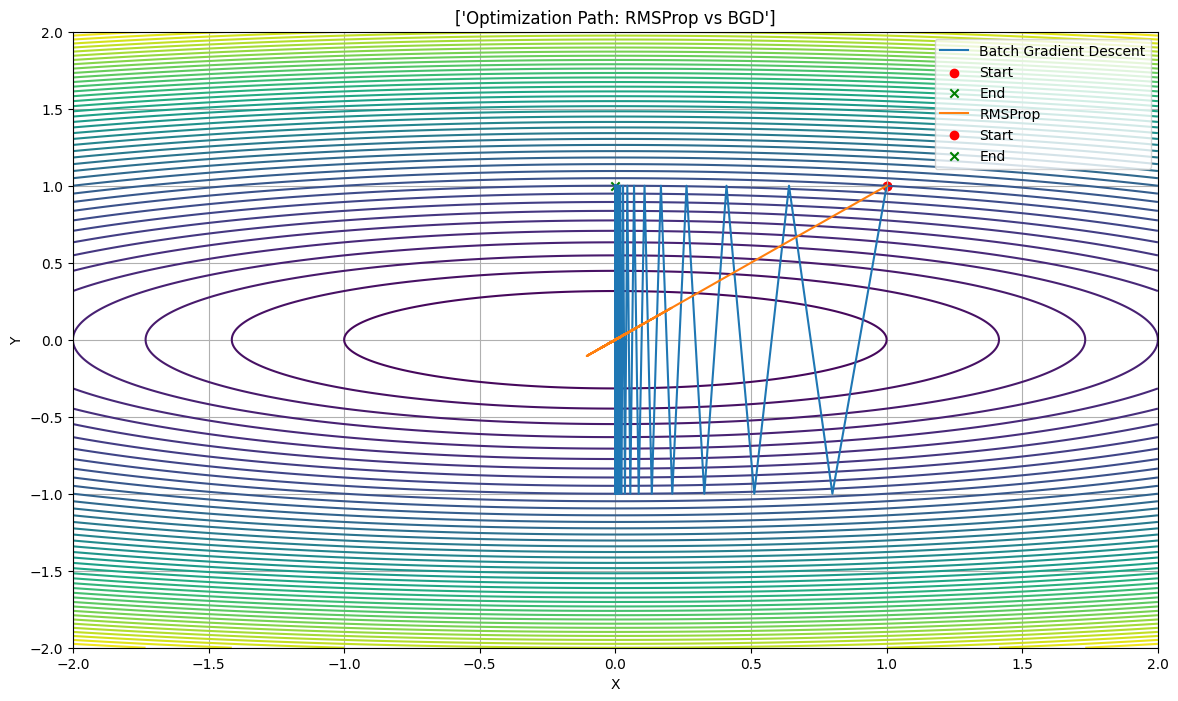

In [77]:
plot_paths(quadratic_loss_function, [path_bgd, path_rms], ["Batch Gradient Descent", "RMSProp"], ["Optimization Path: RMSProp vs BGD"])

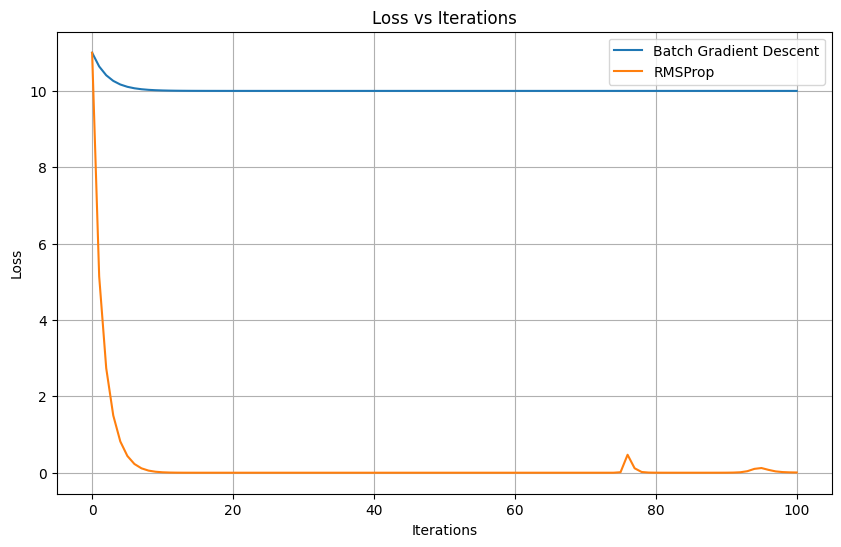

In [78]:
plot_loss([losses_bgd, losses_rms], ["Batch Gradient Descent", "RMSProp"], "Loss vs Iterations")

# Adam Optimizer (Adaptive Moment Estimation)

**Adam** is an advanced optimization algorithm that combines the best properties of two other popular optimizers: **Momentum** and **RMSProp**. It is widely considered the "go-to" optimizer for deep learning because it provides smooth, adaptive updates and handles noisy data or sparse gradients effectively.

---

### 1. The Core Idea: Two Moving Averages
Adam keeps track of two distinct moving averages of the gradients to adjust the learning rate for each parameter independently:

1.  **First Moment ($m_t$):** The mean of the gradients. It represents the **average direction**, similar to Momentum.
2.  **Second Moment ($v_t$):** The variance of the gradients. It represents the **variability or spread** of the gradients.

---

### 2. Mathematical Steps

#### Step 1: Initialize Parameters
At the start ($t=0$), we set our initial moments to zero and define standard hyperparameters:
* $m_0 = 0$ (First moment)
* $v_0 = 0$ (Second moment)
* **Hyperparameters:** $\eta$ (Learning rate), $\beta_1 = 0.9$, $\beta_2 = 0.999$, and $\epsilon = 10^{-8}$ (to avoid division by zero).

#### Step 2: Compute Gradient
Calculate the gradient of the loss function at the current step:
$$g_t = \nabla J(\theta_t)$$

#### Step 3 & 4: Update Biased Moment Estimates
We update the exponentially weighted moving averages:
* **First Moment:** $m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$
* **Second Moment:** $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$

#### Step 5: Bias Correction
Since $m_t$ and $v_t$ are initialized at zero, they are biased toward zero during the initial steps. We correct this by dividing by $(1 - \beta^t)$:
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t} \quad \text{and} \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

#### Step 6: Update Parameters
Finally, update the parameters using the corrected estimates:
$$\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

---

### 3. Key Features of Adam
* **Adaptive Learning Rates:** Adjusts the rate for each parameter based on its recent gradient behavior.
* **Momentum + RMSProp:** Combines direction-based smoothing with magnitude-based scaling.
* **Robustness:** Works exceptionally well for noisy data and sparse gradients.


---

### 4. Implementation Concept
In code, the logic follows the mathematical steps within a loop over your epochs or batches.

```python
# Conceptual Adam Update
m = beta1 * m + (1 - beta1) * grad
v = beta2 * v + (1 - beta2) * (grad**2)

m_hat = m / (1 - beta1**t)
v_hat = v / (1 - beta2**t)

x -= lr * m_hat[0] / (np.sqrt(v_hat[0]) + epsilon)
y -= lr * m_hat[1] / (np.sqrt(v_hat[1]) + epsilon)

In [79]:
import numpy as np
import matplotlib.pyplot as plt

In [80]:
def quadratic_loss_function(x, y):
  return x**2 + 10*y**2

In [81]:
def quadratic_grad(x, y):
  dx = 2 * x
  dy = 20 * y
  return np.array([dx, dy])

In [82]:
def batch_gradient_descent(grad_func, eta, epochs, start_point):
  x, y = start_point
  path = [(x, y)]
  losses = [quadratic_loss_function(x, y)]

  for _ in range(epochs):
    grad = grad_func(x, y)
    x -= eta * grad[0]
    y -= eta * grad[1]
    path.append((x, y))
    losses.append(quadratic_loss_function(x, y))

  return np.array(path), losses

In [83]:
def adam_optimizer(grad_func, lr, beta1, beta2, epsilon, epochs, start_point):
  x, y = start_point
  m = np.array([0.0, 0.0])
  v = np.array([0.0, 0.0])
  path = [(x, y)]
  losses = [quadratic_loss_function(x, y)]

  for i in range(1, epochs+1):
    grad = grad_func(x, y)

    ## update bias for first moment estimate
    m = beta1 * m + (1 - beta1) * grad

    ## update bias for second moment estimate
    v = beta2 * v + (1 - beta2) * (grad ** 2)

    ## bias correction
    m_hat = m / (1 - beta1 ** i)
    v_hat = v / (1 - beta2 ** i)

    ## update parameters
    x -= lr * m_hat[0] / (np.sqrt(v_hat[0]) + epsilon)
    y -= lr * m_hat[1] / (np.sqrt(v_hat[1]) + epsilon)

    path.append((x, y))
    losses.append(quadratic_loss_function(x, y))

  return np.array(path), losses

In [84]:
def plot_paths(grad_function, paths, labels, title):
  x, y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
  z = grad_function(x, y)

  plt.figure(figsize=(14, 8))
  plt.contour(x, y, z, levels=50, cmap='viridis')

  for path, label in zip(paths, labels):
    plt.plot(path[:, 0], path[:, 1], label=label)
    plt.scatter(path[0, 0], path[0, 1], color='red', marker='o', label='Start')
    plt.scatter(path[-1, 0], path[-1, 1], color='green', marker='x', label='End')

  plt.title(title)
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.legend()
  plt.grid(True)
  plt.savefig("Optimization Path: Adam vs BGD.png")
  plt.show()

In [85]:
def plot_loss(losses, labels, title):
  plt.figure(figsize=(10, 6))

  for loss, label in zip(losses, labels):
    plt.plot(loss, label=label)

  plt.title(title)
  plt.xlabel('Iterations')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.savefig("Loss vs Iterations: Adam vs BGD.png")
  plt.show()

In [86]:
path_bgd, loss_bgd = batch_gradient_descent(
                      grad_func=quadratic_grad,
                      eta=0.1,
                      epochs=100,
                      start_point=(1.0, 1.0)
                    )

path_adam, loss_adam = adam_optimizer(
                      grad_func=quadratic_grad,
                      lr=0.1,
                      beta1=0.9,
                      beta2=0.999,
                      epsilon=1e-8,
                      epochs=100,
                      start_point=(1.0, 1.0)
                    )

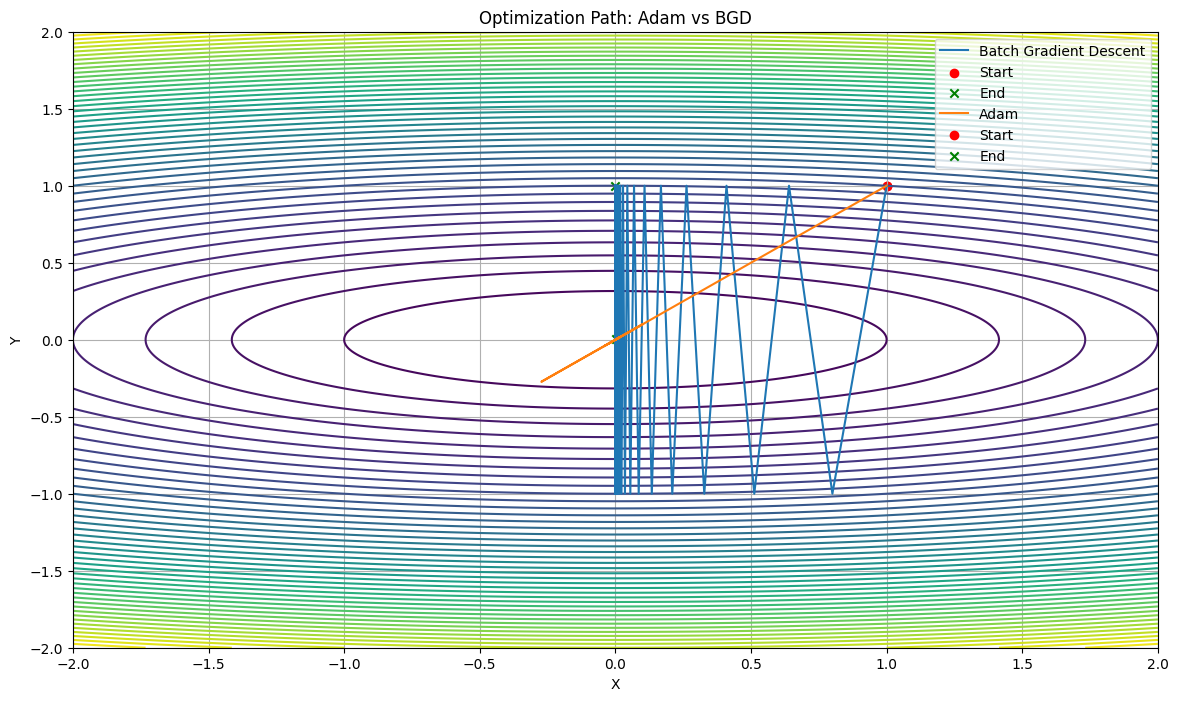

In [87]:
plot_paths(quadratic_loss_function, [path_bgd, path_adam], ["Batch Gradient Descent", "Adam"], "Optimization Path: Adam vs BGD")

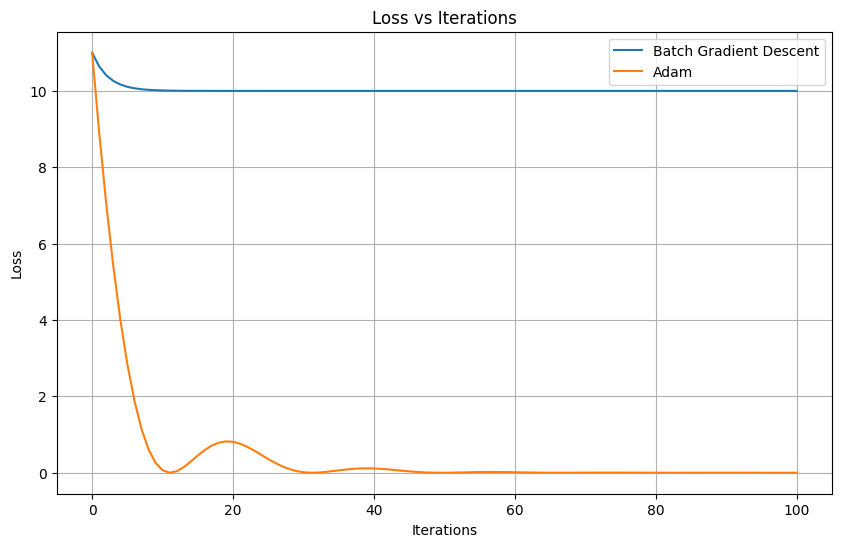

In [88]:
plot_loss([loss_bgd, loss_adam], ["Batch Gradient Descent", "Adam"], "Loss vs Iterations")